# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data

In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering

### Import Libraries and Define Auxiliary Functions


In [1]:
#--- HEADER: LIBRARY IMPORTS FOR EDA AND VISUALIZATION
#--- Importing essential libraries for data manipulation, numerical operations,
#--- and data visualization.

# pandas is a software library written for the Python programming language 
# for data manipulation and analysis.
import pandas as pd

# NumPy is a library for the Python programming language, adding support for 
# large, multi-dimensional arrays and matrices, along with a large collection 
# of high-level mathematical functions to operate on these arrays.
import numpy as np

# Matplotlib is a plotting library for python and pyplot gives us a MatLab 
# like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt

# Seaborn is a Python data visualization library based on matplotlib. 
# It provides a high-level interface for drawing attractive and informative 
# statistical graphics.
import seaborn as sns

## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary

In [2]:
"""
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)
"""

#--- HEADER: LOAD THE CLEANED DATASET WITH CLASS LABEL
#--- Loading the dataset that includes the 'Class' column (target variable)
#--- from the previous lab. The file is loaded locally to ensure reliability.

# Load the dataset from the local CSV file
df = pd.read_csv('/home/mapa8/Documents/CIDSPC/MFaD/C10_M1_C_dataset_part_2.csv')

# Display the first 5 rows to verify the data loaded correctly
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.


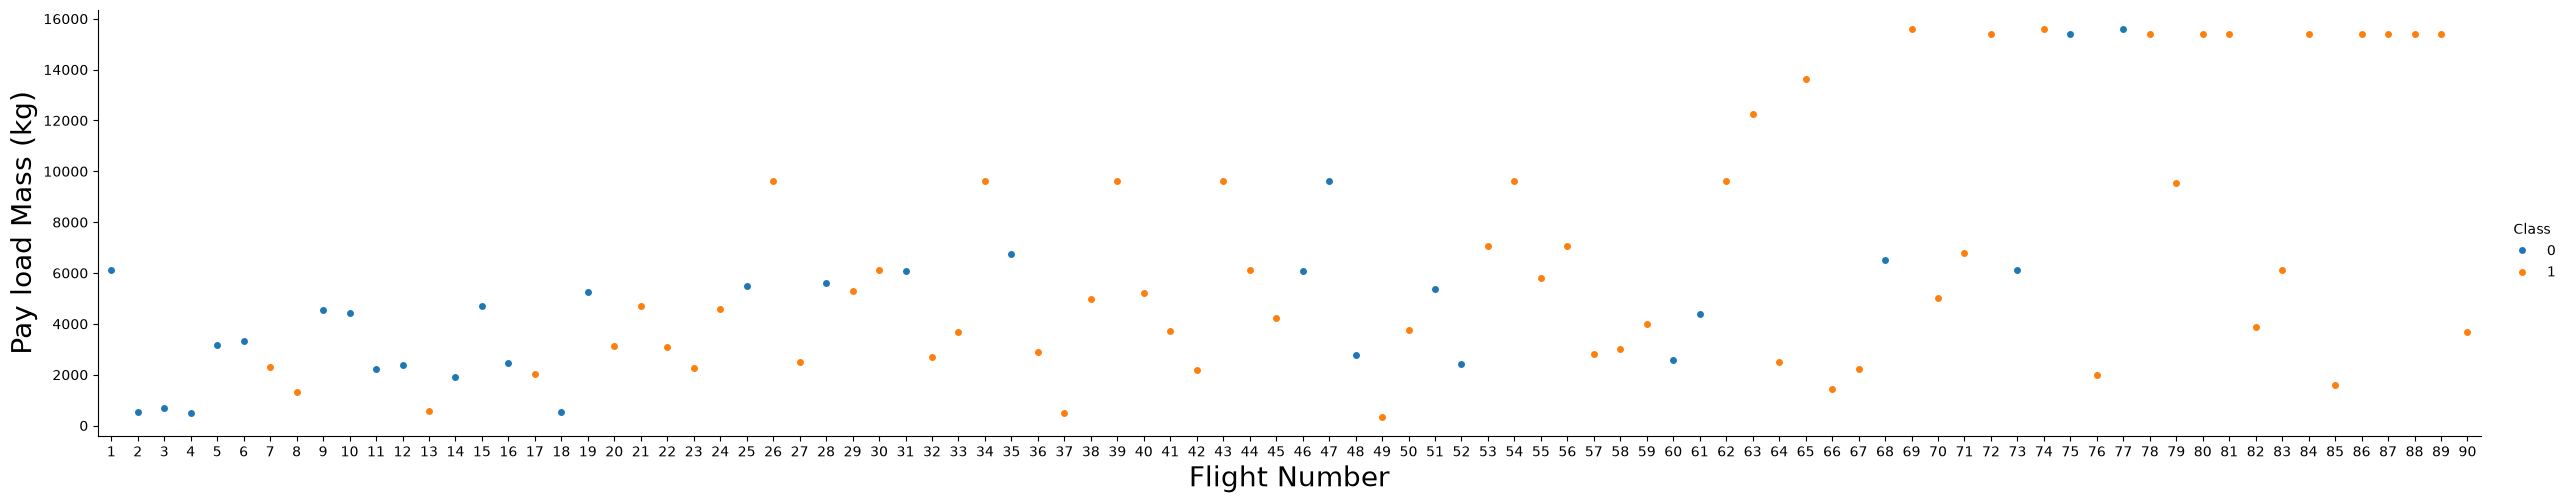

In [3]:
#--- HEADER: CATEGORICAL PLOT - PAYLOAD MASS VS FLIGHT NUMBER
#--- Creating a categorical scatter plot to visualize the relationship
#--- between Flight Number and Payload Mass, colored by landing success (Class).

# catplot() creates a categorical plot with FlightNumber on x-axis and PayloadMass on y-axis.
# hue="Class" colors the points based on landing success (1=success, 0=failure).
# aspect=5 makes the plot wider for better readability of the x-axis.
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)

# Set the x-axis label with larger font size for better readability.
plt.xlabel("Flight Number", fontsize=20)

# Set the y-axis label with larger font size.
plt.ylabel("Pay load Mass (kg)", fontsize=20)

# Display the plot.
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


In [4]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value

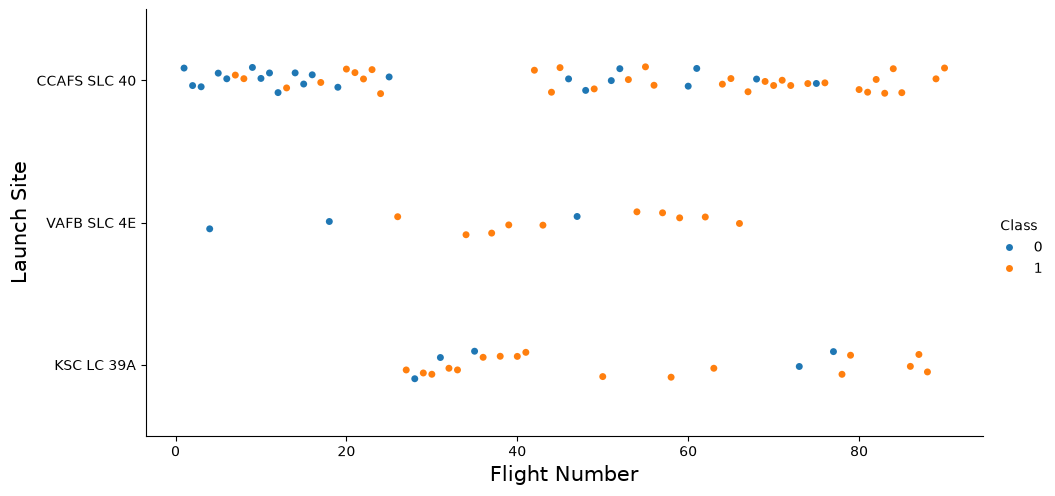

In [5]:
#--- HEADER: TASK 1 - VISUALIZE FLIGHT NUMBER VS LAUNCH SITE
#--- Creating a categorical scatter plot to show the distribution of
#--- launches across different sites over time, colored by landing success.

# catplot() creates a categorical plot with FlightNumber on x-axis and LaunchSite on y-axis.
# hue="Class" colors the points based on landing success (1=success, 0=failure).
# aspect=2 makes the plot wider for better readability.
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=2)

# Set the x-axis label with larger font size.
plt.xlabel("Flight Number", fontsize=15)

# Set the y-axis label with larger font size.
plt.ylabel("Launch Site", fontsize=15)

# Display the plot.
plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.

In [6]:
# NOTE nah

### TASK 2: Visualize the relationship between Payload Mass and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.

In [7]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value

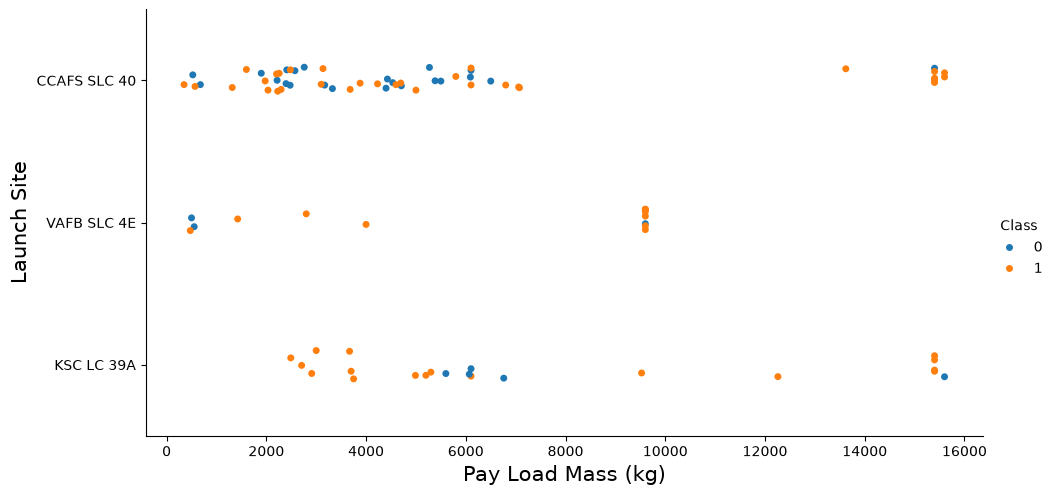

In [8]:
#--- HEADER: TASK 2 - VISUALIZE PAYLOAD MASS VS LAUNCH SITE
#--- Creating a categorical scatter plot to show the distribution of
#--- payload masses across different launch sites, colored by landing success.

# catplot() creates a categorical plot with PayloadMass on x-axis and LaunchSite on y-axis.
# hue="Class" colors the points based on landing success (1=success, 0=failure).
# aspect=2 makes the plot wider for better readability.
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=2)

# Set the x-axis label with larger font size.
plt.xlabel("Pay Load Mass (kg)", fontsize=15)

# Set the y-axis label with larger font size.
plt.ylabel("Launch Site", fontsize=15)

# Display the plot.
plt.show()

Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).

### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.

Let's create a `bar chart` for the sucess rate of each orbit

In [9]:
# HINT use groupby method on Orbit column and get the mean of Class column

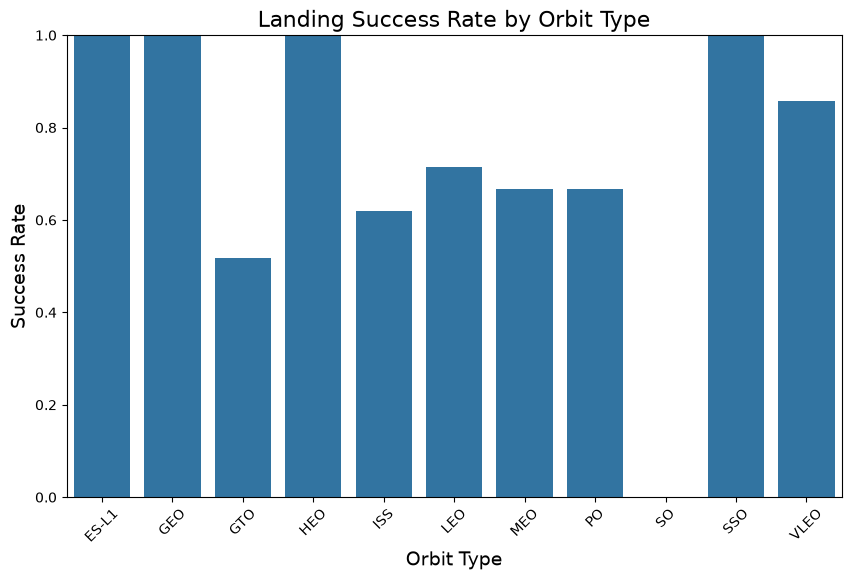

In [10]:
#--- HEADER: TASK 3 - VISUALIZE SUCCESS RATE BY ORBIT TYPE
#--- Creating a bar chart to show the landing success rate for each orbit type.

# Group by Orbit and calculate the mean of Class (success rate)
# .groupby('Orbit') groups data by each unique orbit type
# ['Class'].mean() calculates the average of Class (1=success, 0=failure) for each group
# .reset_index() converts the grouped result back to a DataFrame for plotting
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()

# Create a bar chart with orbit on x-axis and success rate on y-axis
# plt.figure(figsize=(10, 6)) sets the plot size to 10 inches wide and 6 inches tall
plt.figure(figsize=(10, 6))
# sns.barplot() creates a bar chart with orbit types on x-axis and success rates on y-axis
sns.barplot(x='Orbit', y='Class', data=orbit_success)

# Set the y-axis limit to show success rates from 0 to 1 (0% to 100%)
plt.ylim(0, 1)

# Set the x-axis label with font size 14
plt.xlabel("Orbit Type", fontsize=14)

# Set the y-axis label with font size 14
plt.ylabel("Success Rate", fontsize=14)

# Set the title of the plot with font size 16
plt.title("Landing Success Rate by Orbit Type", fontsize=16)

# Rotate x-axis labels by 45 degrees for better readability when labels overlap
plt.xticks(rotation=45)

# Display the plot
plt.show()

Analyze the plotted bar chart to identify which orbits have the highest success rates.

### TASK  4: Visualize the relationship between FlightNumber and Orbit type

For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.

In [11]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value

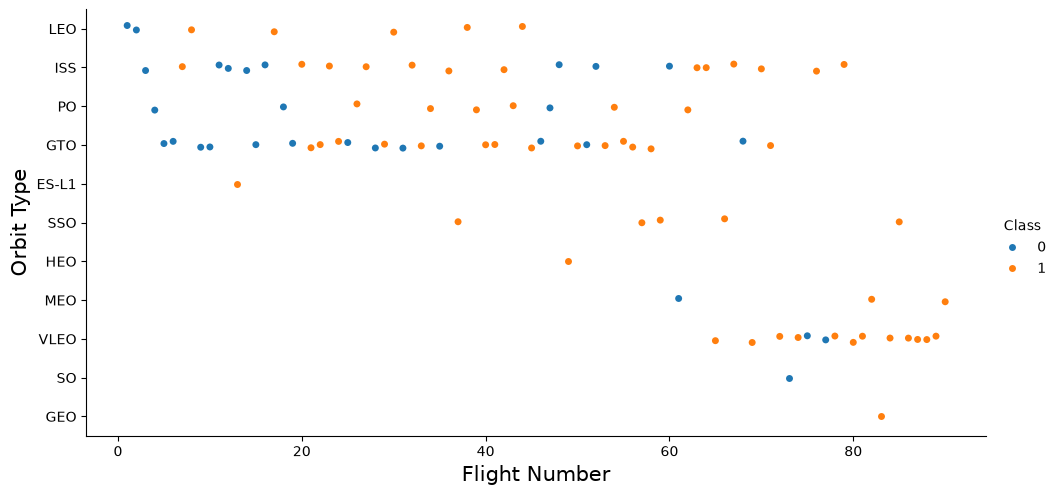

In [12]:
#--- HEADER: TASK 4 - VISUALIZE FLIGHT NUMBER VS ORBIT TYPE
#--- Creating a categorical scatter plot to show the distribution of
#--- orbit types across flight numbers, colored by landing success.

# catplot() creates a categorical plot with FlightNumber on x-axis and Orbit on y-axis.
# hue="Class" colors the points based on landing success (1=success, 0=failure).
# aspect=2 makes the plot wider for better readability.
sns.catplot(x="FlightNumber", y="Orbit", hue="Class", data=df, aspect=2)

# Set the x-axis label with larger font size.
plt.xlabel("Flight Number", fontsize=15)

# Set the y-axis label with larger font size.
plt.ylabel("Orbit Type", fontsize=15)

# Display the plot.
plt.show()

You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.


### TASK  5: Visualize the relationship between Payload Mass and Orbit type


Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type

In [13]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value

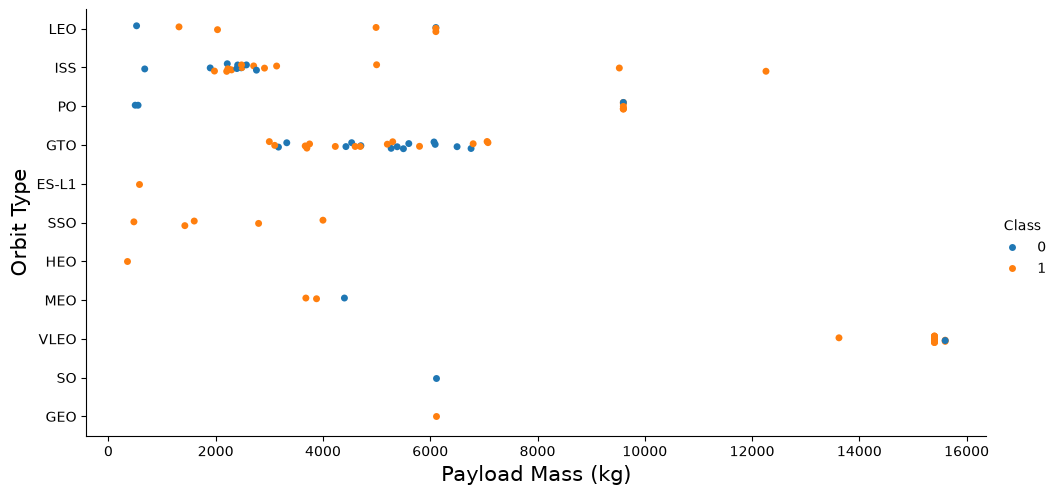

In [14]:
#--- HEADER: TASK 5 - VISUALIZE PAYLOAD MASS VS ORBIT TYPE
#--- Creating a categorical scatter plot to show the distribution of
#--- payload masses across different orbit types, colored by landing success.

# catplot() creates a categorical plot with PayloadMass on x-axis and Orbit on y-axis.
# hue="Class" colors the points based on landing success (1=success, 0=failure).
# aspect=2 makes the plot wider for better readability.
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=2)

# Set the x-axis label with larger font size.
plt.xlabel("Payload Mass (kg)", fontsize=15)

# Set the y-axis label with larger font size.
plt.ylabel("Orbit Type", fontsize=15)

# Display the plot.
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.


### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.

The function will help you get the year from the date:

In [15]:
#--- HEADER: TASK 6 - EXTRACT YEAR FROM DATE FOR YEARLY TREND ANALYSIS
#--- Creating a function to extract the year from the Date column
#--- and adding it as a new column for yearly trend analysis.

# Initialize an empty list to store extracted years
year = []

# Define a function to extract the year from each date
# .split("-") splits the date string into [year, month, day]
# [0] takes the first element (year)
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year

# Call the function to populate the year list
Extract_year()

# Replace the Date column with the extracted year values
df['Date'] = year

# Display the first few rows to verify the change
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [16]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate

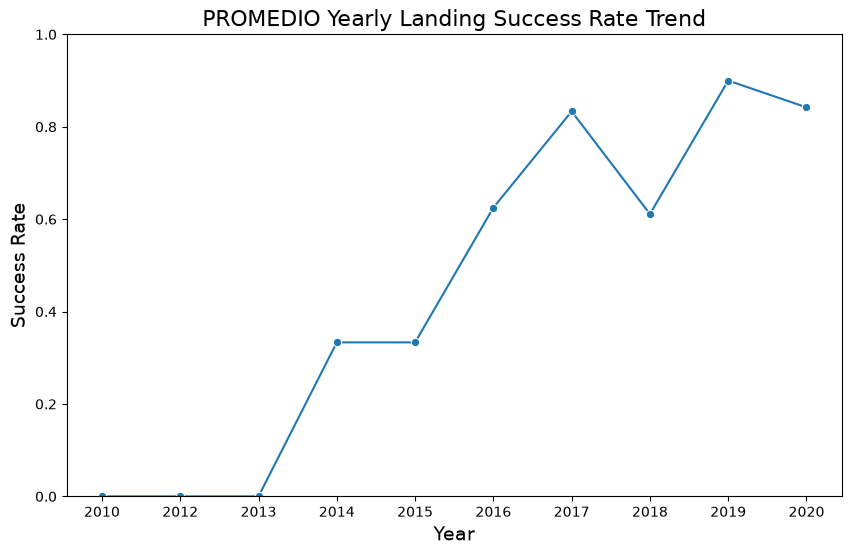

In [17]:
#--- HEADER: TASK 6 - VISUALIZE YEARLY LAUNCH SUCCESS TREND
#--- Creating a line chart to show the landing success rate trend over the years.

# Group by year and calculate the mean of Class (success rate)
# .groupby('Date') groups data by each unique year
# ['Class'].mean() calculates the average of Class (1=success, 0=failure) for each year
# .reset_index() converts the grouped result back to a DataFrame for plotting
yearly_success = df.groupby('Date')['Class'].mean().reset_index()

# Create a line chart with year on x-axis and success rate on y-axis
# plt.figure(figsize=(10, 6)) sets the plot size to 10 inches wide and 6 inches tall
plt.figure(figsize=(10, 6))

# sns.lineplot() creates a line chart with years on x-axis and success rates on y-axis
# marker='o' adds circular markers at each data point for better visibility
sns.lineplot(x='Date', y='Class', data=yearly_success, marker='o')

# Set the y-axis limit to show success rates from 0 to 1 (0% to 100%)
plt.ylim(0, 1)

# Set the x-axis label with font size 14
plt.xlabel("Year", fontsize=14)

# Set the y-axis label with font size 14
plt.ylabel("Success Rate", fontsize=14)

# Set the title of the plot with font size 16
plt.title("PROMEDIO Yearly Landing Success Rate Trend", fontsize=16) # NOTE mìo "PROMEDIO"

# Display the plot
plt.show()

you can observe that the sucess rate since 2013 kept increasing till 2020


## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.

In [18]:
#--- HEADER: FEATURE SELECTION FOR MODELING
#--- Creating a subset of the DataFrame containing only the features
#--- that will be used for predictive modeling.

# Select relevant features for the model
# FlightNumber - chronological order of launches
# PayloadMass - weight of payload in kg
# Orbit - target orbit type
# LaunchSite - launch location
# Flights - number of flights for this core
# GridFins - presence of grid fins (True/False)
# Reused - whether the core was reused (True/False)
# Legs - presence of landing legs (True/False)
# LandingPad - landing pad used
# Block - booster version block number
# ReusedCount - number of times core has been reused
# Serial - core serial number
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]

# Display the first few rows to verify the feature selection
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [19]:
# HINT: Use get_dummies() function on the categorical columns

In [20]:
#--- HEADER: TASK 7 - CREATE DUMMY VARIABLES FOR CATEGORICAL COLUMNS
#--- Applying OneHotEncoder using pandas get_dummies() to convert
#--- categorical columns into numerical dummy variables for modeling.

# Use get_dummies() to convert categorical columns to dummy variables
# columns parameter specifies which columns to encode
# drop_first=False keeps all categories (no reference category dropped)
# The result includes all original features plus the encoded ones
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'], drop_first=False)

# Display the first few rows to verify the encoding
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code>

In [21]:
# HINT: use astype function

In [22]:
#--- HEADER: TASK 8 - CAST ALL NUMERIC COLUMNS TO FLOAT64
#--- Converting all columns in the features_one_hot DataFrame to float64
#--- to ensure compatibility with machine learning models.

# astype('float64') converts all columns to float64 data type
# This ensures all features are numeric and consistent for modeling
features_one_hot = features_one_hot.astype('float64')

# Display the first few rows to verify the conversion
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


In [23]:
#--- HEADER: SAVE FEATURES DATASET TO CSV
#--- Saving the one-hot encoded features DataFrame to a CSV file
#--- for use in the next stage of the capstone project (modeling).

# index=False prevents pandas from writing row numbers to the CSV file.
# This keeps the CSV clean and ensures only your data columns are saved.
features_one_hot.to_csv('C10_M2_B_dataset_part_3.csv', index=False)